In [30]:
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt

In [31]:
apps_df = pd.read_csv("googleplaystore.csv")

reviews_df = pd.read_csv(
    "googleplaystore_user_reviews.csv",
    encoding="latin1",
    on_bad_lines="skip"
)

print("=== STEP 1: DATA LOADED ===")
print("Apps Shape   :", apps_df.shape)
print("Reviews Shape:", reviews_df.shape)
print("\nApps Columns:")
print(apps_df.columns.tolist())
print("\nReviews Columns:")
print(reviews_df.columns.tolist())



=== STEP 1: DATA LOADED ===
Apps Shape   : (10841, 13)
Reviews Shape: (64294, 5)

Apps Columns:
['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']

Reviews Columns:
['App', 'Translated_Review', 'Sentiment', 'Sentiment_Polarity', 'Sentiment_Subjectivity']


In [32]:
print("\n=== STEP 2: SENTIMENT PREPROCESSING ===")
print("Missing Sentiment_Polarity:",
      reviews_df['Sentiment_Polarity'].isna().sum())

reviews_df = reviews_df.dropna(subset=['Sentiment_Polarity'])
print("After dropna Reviews Shape:", reviews_df.shape)

sentiment_agg = reviews_df.groupby('App').agg({
    'Sentiment_Polarity': 'mean',
    'Sentiment_Subjectivity': 'mean'
}).reset_index()


sentiment_agg = sentiment_agg.rename(columns={
    'Sentiment_Polarity': 'Avg_Sentiment_Polarity',
    'Sentiment_Subjectivity': 'Avg_Sentiment_Subjectivity'
})

print("Sentiment Aggregated Columns:")
print(sentiment_agg.columns.tolist())
print("\nSentiment Preview:")
print(sentiment_agg.head().to_string(index=False))




=== STEP 2: SENTIMENT PREPROCESSING ===
Missing Sentiment_Polarity: 26863
After dropna Reviews Shape: (37431, 5)
Sentiment Aggregated Columns:
['App', 'Avg_Sentiment_Polarity', 'Avg_Sentiment_Subjectivity']

Sentiment Preview:
                             App  Avg_Sentiment_Polarity  Avg_Sentiment_Subjectivity
           10 Best Foods for You                0.470733                    0.495455
104 ??? - ??? ??? ??? ???? ?????                0.392405                    0.545516
                            11st                0.181294                    0.443957
      1800 Contacts - Lens Store                0.318145                    0.591098
 1LINE  One Line with One Touch                0.196290                    0.557315


In [33]:
df = apps_df.merge(sentiment_agg, on='App', how='left')

print("\n=== STEP 3: MERGE ===")
print("Merged Shape:", df.shape)
print("Merged Columns:")
print(df.columns.tolist())
print("\nMissing Sentiment After Merge:")
print(df[['Avg_Sentiment_Polarity',
          'Avg_Sentiment_Subjectivity']].isna().sum())



=== STEP 3: MERGE ===
Merged Shape: (10841, 15)
Merged Columns:
['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver', 'Avg_Sentiment_Polarity', 'Avg_Sentiment_Subjectivity']

Missing Sentiment After Merge:
Avg_Sentiment_Polarity        9678
Avg_Sentiment_Subjectivity    9678
dtype: int64


In [34]:
print("sentiment_agg columns:")
print(sentiment_agg.columns.tolist())



sentiment_agg columns:
['App', 'Avg_Sentiment_Polarity', 'Avg_Sentiment_Subjectivity']


In [36]:
print("\n=== STEP 4: CLEANING ===")

df = df.copy()  # SettingWithCopyWarning

print("Missing Rating before:", df['Rating'].isna().sum())
df = df.loc[df['Rating'].notna()]
print("After drop Rating NA:", df.shape)

# Reviews
df.loc[:, 'Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')

# Installs
df.loc[:, 'Installs'] = (
    df['Installs']
    .astype(str)
    .str.replace('[+,]', '', regex=True)
)
df.loc[:, 'Installs'] = pd.to_numeric(df['Installs'], errors='coerce')

# Price
df.loc[:, 'Price'] = (
    df['Price']
    .astype(str)
    .str.replace('$', '', regex=True)
)
df.loc[:, 'Price'] = pd.to_numeric(df['Price'], errors='coerce')

# Sentiment
df.loc[:, 'Avg_Sentiment_Polarity'] = pd.to_numeric(
    df['Avg_Sentiment_Polarity'], errors='coerce'
)
df.loc[:, 'Avg_Sentiment_Subjectivity'] = pd.to_numeric(
    df['Avg_Sentiment_Subjectivity'], errors='coerce'
)

print("\nMissing values before final drop:")
print(df.isna().sum())

df = df.dropna()

print("Final Shape after cleaning:", df.shape)



=== STEP 4: CLEANING ===
Missing Rating before: 1474
After drop Rating NA: (9367, 15)

Missing values before final drop:
App                              0
Category                         0
Rating                           0
Reviews                          1
Size                             0
Installs                         1
Type                             0
Price                          648
Content Rating                   1
Genres                           0
Last Updated                     0
Current Ver                      4
Android Ver                      3
Avg_Sentiment_Polarity        8205
Avg_Sentiment_Subjectivity    8205
dtype: int64
Final Shape after cleaning: (1147, 15)


In [37]:
print("\n=== STEP 5: FEATURES & TARGET ===")

features = [
    'Reviews',
    'Installs',
    'Price',
    'Avg_Sentiment_Polarity',
    'Avg_Sentiment_Subjectivity'
]

X = df[features].values
y = df['Rating'].values

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nRating Statistics:")
print(pd.Series(y).describe())



=== STEP 5: FEATURES & TARGET ===
X shape: (1147, 5)
y shape: (1147,)

Rating Statistics:
count    1147.000000
mean        4.295554
std         0.305573
min         2.600000
25%         4.200000
50%         4.300000
75%         4.500000
max         4.900000
dtype: float64


In [38]:
print("\n=== STEP 5: FEATURES & TARGET ===")

features = [
    'Reviews',
    'Installs',
    'Price',
    'Avg_Sentiment_Polarity',
    'Avg_Sentiment_Subjectivity'
]

X = df[features].values
y = df['Rating'].values

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nRating Statistics:")
print(pd.Series(y).describe())



=== STEP 5: FEATURES & TARGET ===
X shape: (1147, 5)
y shape: (1147,)

Rating Statistics:
count    1147.000000
mean        4.295554
std         0.305573
min         2.600000
25%         4.200000
50%         4.300000
75%         4.500000
max         4.900000
dtype: float64


In [39]:
print("\n=== STEP 6: SPLIT & SCALING ===")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size :", X_test.shape)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Scaling completed ✔")



=== STEP 6: SPLIT & SCALING ===
Train size: (917, 5)
Test size : (230, 5)
Scaling completed ✔


In [40]:
print("\n=== STEP 7: TENSORS ===")

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1,1)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1,1)

print("X_train_t:", X_train_t.shape)
print("y_train_t:", y_train_t.shape)

train_ds = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)



=== STEP 7: TENSORS ===
X_train_t: torch.Size([917, 5])
y_train_t: torch.Size([917, 1])


In [42]:
print("\n=== STEP 8: MODEL DEFINITION ===")

class RatingNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.net(x)

model = RatingNN(X_train.shape[1])
print(model)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)




=== STEP 8: MODEL DEFINITION ===
RatingNN(
  (net): Sequential(
    (0): Linear(in_features=5, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
  )
)


In [43]:
print("\n=== STEP 9: TRAINING ===")

epochs = 50
losses = []

for epoch in range(epochs):
    model.train()
    epoch_loss = 0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    losses.append(epoch_loss)
    print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.4f}")



=== STEP 9: TRAINING ===
Epoch 1/50 - Loss: 470.5913
Epoch 2/50 - Loss: 374.4495
Epoch 3/50 - Loss: 234.0967
Epoch 4/50 - Loss: 109.4216
Epoch 5/50 - Loss: 58.5231
Epoch 6/50 - Loss: 42.8001
Epoch 7/50 - Loss: 33.3354
Epoch 8/50 - Loss: 26.3516
Epoch 9/50 - Loss: 21.1541
Epoch 10/50 - Loss: 17.0552
Epoch 11/50 - Loss: 13.6275
Epoch 12/50 - Loss: 11.3098
Epoch 13/50 - Loss: 9.2715
Epoch 14/50 - Loss: 7.7448
Epoch 15/50 - Loss: 6.5185
Epoch 16/50 - Loss: 5.5532
Epoch 17/50 - Loss: 4.9196
Epoch 18/50 - Loss: 4.3862
Epoch 19/50 - Loss: 4.0428
Epoch 20/50 - Loss: 3.8074
Epoch 21/50 - Loss: 3.5709
Epoch 22/50 - Loss: 3.4145
Epoch 23/50 - Loss: 3.2489
Epoch 24/50 - Loss: 3.1169
Epoch 25/50 - Loss: 3.0116
Epoch 26/50 - Loss: 2.9195
Epoch 27/50 - Loss: 2.8481
Epoch 28/50 - Loss: 2.8200
Epoch 29/50 - Loss: 2.7111
Epoch 30/50 - Loss: 2.6343
Epoch 31/50 - Loss: 2.5822
Epoch 32/50 - Loss: 2.5369
Epoch 33/50 - Loss: 2.4842
Epoch 34/50 - Loss: 2.4306
Epoch 35/50 - Loss: 2.3954
Epoch 36/50 - Loss: 2.


=== STEP 10: LOSS CURVE ===


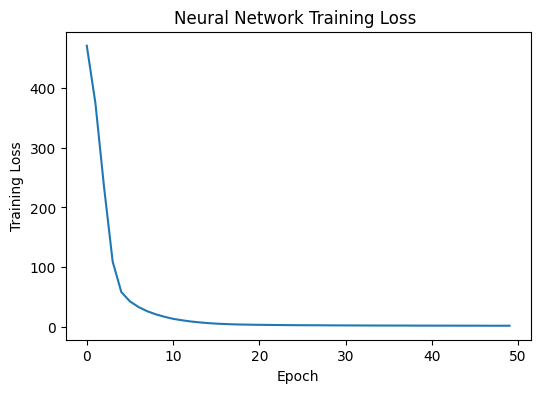

In [48]:
print("\n=== STEP 10: LOSS CURVE ===")

plt.figure(figsize=(6,4))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Neural Network Training Loss ")
plt.show()


In [45]:
print("\n=== STEP 11: EVALUATION ===")

model.eval()
with torch.no_grad():
    y_pred_nn = model(X_test_t).numpy().flatten()

print("MAE :", mean_absolute_error(y_test, y_pred_nn))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_nn)))
print("R²  :", r2_score(y_test, y_pred_nn))



=== STEP 11: EVALUATION ===
MAE : 0.18650469551915713
RMSE: 0.251526310215192
R²  : 0.23459078414317447



=== STEP 12: ACTUAL VS PREDICTED ===


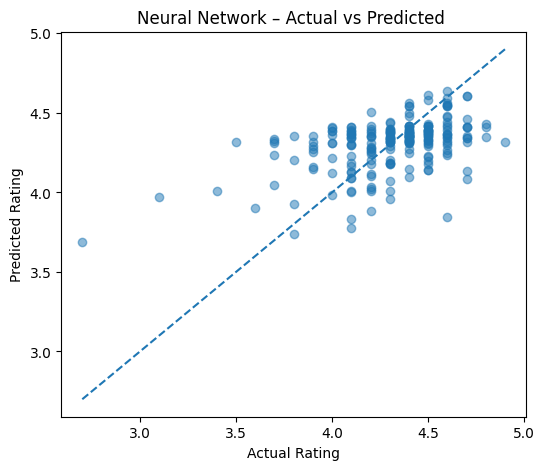

In [47]:
print("\n=== STEP 12: ACTUAL VS PREDICTED ===")

plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred_nn, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')

plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Neural Network – Actual vs Predicted ")
plt.show()
